In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score


df = pd.read_csv('Fish.csv')

display(df.head())

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


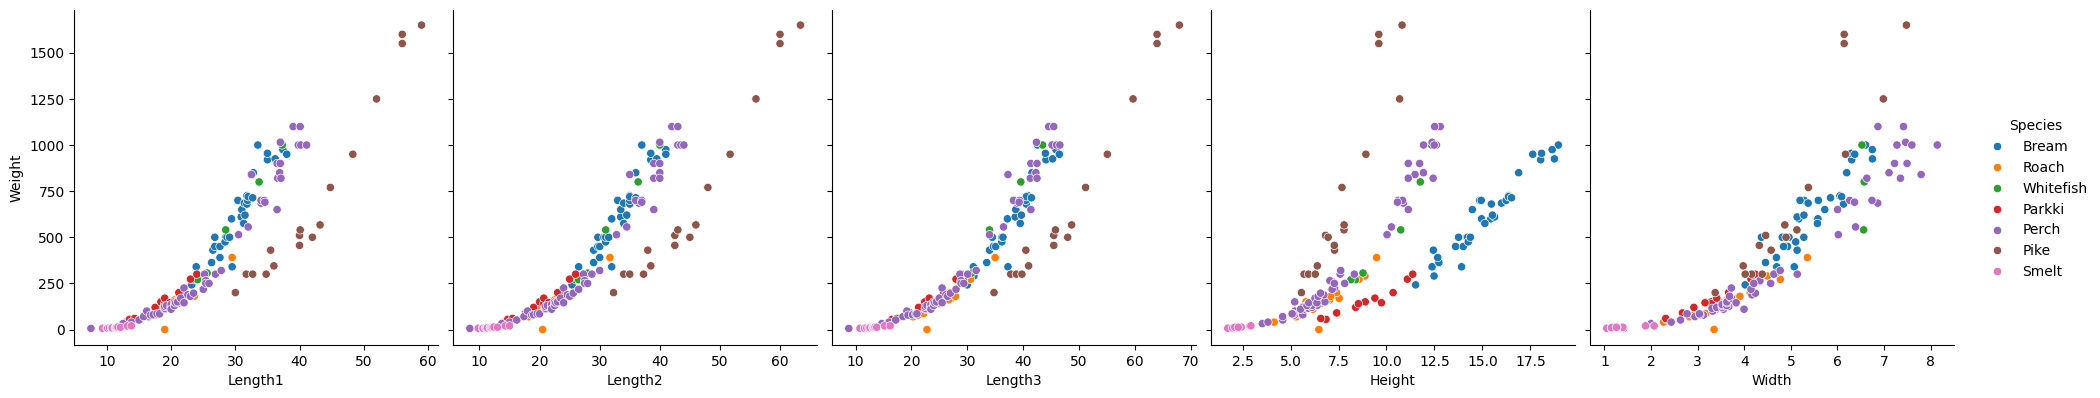

In [13]:
sns.pairplot(df, 
             x_vars=['Length1', 'Length2', 'Length3', 'Height', 'Width'], 
             y_vars=['Weight'], 
             hue='Species', 
             height=4)

plt.show()

In [14]:
X = df.drop('Weight', axis=1)
y = df['Weight']

categorical_features = ['Species']
numerical_features = ['Length1', 'Length2', 'Length3', 'Height', 'Width']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge(alpha=1.0)) # You can tune alpha for better results
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Pipeline created successfully.")

Pipeline created successfully.


In [15]:
baseline = DummyRegressor(strategy="mean")
baseline.fit(X_train, y_train)
y_pred_baseline = baseline.predict(X_test)

model_pipeline.fit(X_train, y_train)
y_pred_ridge = model_pipeline.predict(X_test)

print("--- Results Comparison ---")


base_r2 = r2_score(y_test, y_pred_baseline)
base_mse = mean_squared_error(y_test, y_pred_baseline)
base_rmse = base_mse ** 0.5

print(f"Baseline (Mean) R²: {base_r2:.4f}")
print(f"Baseline (Mean) RMSE: {base_rmse:.4f}")


ridge_r2 = r2_score(y_test, y_pred_ridge)

ridge_mse = mean_squared_error(y_test, y_pred_ridge)
ridge_rmse = ridge_mse ** 0.5

print(f"Ridge Model R²:     {ridge_r2:.4f}")
print(f"Ridge Model RMSE:   {ridge_rmse:.4f}")


if ridge_r2 > base_r2:
    print("\nSUCCESS: The Ridge model significantly outperforms the baseline!")
else:
    print("\nCheck model: It is not performing better than the baseline.")

--- Results Comparison ---
Baseline (Mean) R²: -0.0231
Baseline (Mean) RMSE: 381.4741
Ridge Model R²:     0.9465
Ridge Model RMSE:   87.2354

SUCCESS: The Ridge model significantly outperforms the baseline!
